# 🏛️ Curso de Análisis No Lineal de Estructuras
## Modelado de Muros de Concreto Reforzado con Elementos MVLEM y Análisis Pushover
**Profesor:** Orlando Arroyo | **Entorno:** Google Colab / Jupyter Notebook

### 📖 Introducción al Elemento MVLEM
El elemento **MVLEM** (*Multiple-Vertical-Line-Element-Model*, Vulcano et al., 1988; Orakcal & Wallace, 2006; Kolozvari et al., 2015) es un modelo macroscópico bidimensional ampliamente utilizado en la ingeniería sísmica para simular la respuesta no lineal de muros estructurales de concreto reforzado.

**Características fundamentales del elemento MVLEM en OpenSees:**
1. **Discretización en macrofibras verticales:** El muro se divide en $m$ elementos axiales unidimensionales en paralelo, cada uno con su propio espesor $t_i$, ancho tributario $b_i$, cuantía de acero $\rho_i$ y relaciones constitutivas de concreto y acero.
2. **Interacción flexión-carga axial (P-M):** La cinemática de cuerpo rígido en la parte superior e inferior acopla la deformación axial de las macrofibras, capturando de forma natural la migración del eje neutro y la variación del brazo de palanca.
3. **Resorte central de cortante:** Un resorte horizontal ubicado a una altura $c\cdot h$ (típicamente $c = 0.4$) modela la flexibilidad y resistencia a cortante del muro de forma desacoplada o acoplada.
4. **Edificio de estudio:** 16 pisos ($H = 41.6\text{ m}$, $h = 2.6\text{ m}$) con dos muros acoplados mediante vigas de enlace y diafragmas rígidos de piso.

### 📦 1. Instalación Automática de Dependencias en Google Colab

In [1]:
# Detección del entorno: Instalar paquetes solo en Google Colab
import sys
IN_COLAB = 'google.colab' in sys.modules
if not IN_COLAB:
    try:
        import google.colab
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

if IN_COLAB:
    !pip install -q openseespy opseestools opsvis matplotlib numpy pandas scipy
    print("✅ Dependencias instaladas en Google Colab.")
else:
    print("💻 Ejecución local detectada: Se omite pip para proteger tu entorno (openseespy-mac-arm).")


💻 Ejecución local detectada: Se omite pip para proteger tu entorno (openseespy-mac-arm).


### 📚 2. Importación de Librerías y Configuración Gráfica

In [2]:
from openseespy.opensees import *
import matplotlib.pyplot as plt
import opseestools.analisis as an
import opsvis as opsv
import numpy as np
import time

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except:
    plt.style.use("default")
print("✅ Librerías cargadas exitosamente.")

✅ Librerías cargadas exitosamente.


### 📐 3. Geometría del Edificio y Malla Nodal
- **Unidades de trabajo:** Metros $[m]$, Kilonewtons $[kN]$, Kilopascales $[kPa] = [kN/m^2]$.
- **Ejes de muros:** 2 muros acoplados ubicados en $X = [0.0, 9.15]\text{ m}$.
- **Niveles:** 16 pisos de $2.6\text{ m}$ cada uno (altura total $H = 41.6\text{ m}$).
- **Apoyos:** Empotramiento total en la base ($Y = 0$).
- **Diafragmas:** Diafragma horizontal rígido en cada entrepiso (`equalDOF`).

In [3]:
wipe()
model("basic", "-ndm", 2, "-ndf", 3)

xloc = [0.0, 9.15] # Ubicación de los dos muros acoplados [m]
yloc = [0.0, 2.6, 5.2, 7.8, 10.4, 13.0, 15.6, 18.2, 
        20.8, 23.4, 26.0, 28.6, 31.2, 33.8, 36.4, 39.0, 41.6] # 16 pisos de 2.6 m

ny = len(yloc)
nx = len(xloc)
ht = yloc[-1] # Altura total 41.6 m

# Generación de nodos
for i in range(nx):
    for j in range(ny):
        nnode = 1000 * (i + 1) + j
        node(nnode, xloc[i], yloc[j])

# Restricciones en la base
fixY(0.0, 1, 1, 1)

# Diafragmas rígidos de piso (equalDOF en Ux)
for j in range(1, ny):
    for i in range(1, nx):
        masternode = 1000 + j
        slavenode  = 1000 * (i + 1) + j
        equalDOF(masternode, slavenode, 1)

print(f"Modelo inicializado: {nx} muros, {ny-1} pisos (H = {ht} m), diafragmas rígidos activos.")

Modelo inicializado: 2 muros, 16 pisos (H = 41.6 m), diafragmas rígidos activos.


### 🧱 4. Materiales Constitutivos No Lineales
- **Concreto (`Concrete02`):**
  - Concreto no confinado para el alma: $f'_c = 35\text{ MPa} = 35000\text{ kPa}$, $\epsilon_c = 0.0028$, $f_{cu} = 0.1 f'_c$.
  - Concreto confinado para los elementos de borde: $f'_{cc} = 1.3 f'_c = 45.5\text{ MPa}$, $\epsilon_{cc} = 0.0036$, $\epsilon_{ucc} = 0.02$.
- **Acero de refuerzo (`Hysteretic`):**
  - $F_y = 420\text{ MPa} = 420000\text{ kPa}$, $E_s = 210000\text{ MPa}$, $F_u = 630\text{ MPa}$, deformación última $\epsilon_{ult} = 0.10$.
- **Resorte a cortante (`Elastic`):**
  - Rigidez a cortante $G = 0.4 E_c$ asignada al resorte horizontal del MVLEM.

In [4]:
geomTransf("Linear", 1)
geomTransf("PDelta", 2)

# Propiedades del concreto [kPa]
fc = 35000.0
E  = 1000.0 * 4300.0 * (fc / 1000.0)**0.5
ec = 2.0 * fc / E
fcu = 0.1 * fc
ecu = 0.006

# Concreto confinado (Mander k = 1.3)
k = 1.3
fcc = fc * k
ecc = 2.0 * fcc / E
fucc = 0.2 * fcc
eucc = 0.02

# Acero Hysteretic
Fy = 420000.0
Es = 210000000.0
ey = Fy / Es
fu = 630000.0
eult = 0.10

uniaxialMaterial("Concrete02", 1, -fcc, -ecc, -fucc, -eucc)
uniaxialMaterial("Concrete02", 2, -fc,  -ec,  -fcu,  -ecu)
uniaxialMaterial("Hysteretic", 3, Fy, ey, fu, eult, 0.05*Fy, 0.11,
                                  -Fy, -ey, -fu, -eult, -0.05*Fy, -0.11,
                                  1.0, 1.0, 0.0, 0.0)

tagshear = 1000
G = E * 0.4
uniaxialMaterial("Elastic", tagshear, G)
print("Materiales definidos: Concreto confinado (1), Concreto no confinado (2), Acero (3), Cortante (1000).")

Materiales definidos: Concreto confinado (1), Concreto no confinado (2), Acero (3), Cortante (1000).


### 🏢 5. Discretización de los Muros en Elementos MVLEM
Cada muro tiene una longitud total de $L_w = 7.65\text{ m}$, discretizado en **8 macrofibras**:
- 2 fibras de borde de $0.30\text{ m}$ con aletas o sobre-espesor de elemento de borde ($t = 7.5\text{ m}$ o $0.30\text{ m}$ según la orientación).
- 6 fibras centrales de alma de $1.175\text{ m}$ de ancho con espesor de $0.30\text{ m}$.
- Cuantía de acero: $\rho = 1.2\%$ en bordes y alma.
- Parámetro del centro de rotación: $c = 0.4$.

In [5]:
width = [0.30, 1.175, 1.175, 1.175, 1.175, 1.175, 1.175, 0.30]
nfib = len(width) # 8 fibras
cMVLEM = 0.4

# Espesores por fibra [m]
t1 = [7.5, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3] # Muro 1
t2 = [0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 7.5] # Muro 2

rho = [0.012] * nfib # Cuantía 1.2%
concTags  = [1] + [2] * (nfib - 2) + [1] # Confinado en bordes, no confinado en alma
steelTags = [3] * nfib
shearTags = [tagshear] * nfib

for i, thick in enumerate([t2, t1]):
    for j in range(ny - 1):
        nodeI = 1000 * (i + 1) + j
        nodeJ = 1000 * (i + 1) + (j + 1)
        eltag = 1000 * (i + 1) + j
        element("MVLEM", eltag, 0.0, nodeI, nodeJ, nfib, cMVLEM,
                "-thick", *thick, "-width", *width, "-rho", *rho,
                "-matConcrete", *concTags, "-matSteel", *steelTags, "-matShear", *shearTags)

print(f"Se generaron {nx * (ny - 1)} elementos MVLEM en los 16 pisos.")

Se generaron 32 elementos MVLEM en los 16 pisos.


### 🌉 6. Vigas de Enlace / Acople entre Muros
Vigas elásticas de sección $0.30\times 0.50\text{ m}$ conectando ambos muros en cada nivel de entrepiso.

In [6]:
bv = 0.30
hv = 0.50
Av = bv * hv
Iv = bv * hv**3 / 12.0
Ev = 24000000.0 # kPa

tagvigas = []
for j in range(1, ny):
    nodeI = 1000 + j
    nodeJ = 2000 + j
    eltag = 100000 + j
    tagvigas.append(eltag)
    element("elasticBeamColumn", eltag, nodeI, nodeJ, Av, Ev, Iv, 1)

print(f"{len(tagvigas)} vigas de acople generadas entre muros.")

16 vigas de acople generadas entre muros.


### ⚖️ 7. Cargas Gravitacionales y Peso Sísmico
Aplicamos una carga vertical puntual de $-797.5\text{ kN}$ por muro en cada nivel de piso.

In [7]:
P_gravity = -797.5 # kN por muro por piso

timeSeries("Linear", 1)
pattern("Plain", 1, 1)
for i in range(nx):
    for j in range(ny - 1):
        nodeJ = 1000 * (i + 1) + (j + 1)
        load(nodeJ, 0.0, P_gravity, 0.0)

W_total = nx * (ny - 1) * abs(P_gravity) # Peso total [kN]
print(f"Carga vertical aplicada. Peso sísmico total W = {W_total:.1f} kN.")

# Análisis de gravedad
an.gravedad()
loadConst("-time", 0.0)
print("✅ Gravedad completada exitosamente.")

Carga vertical aplicada. Peso sísmico total W = 25520.0 kN.
✅ Gravedad completada exitosamente.


### 🎯 8. Configuración del Patrón de Carga Lateral (Pushover)
Seleccionamos el patrón de empuje lateral:
- `pushtype = 1`: Patrón triangular proporcional a la altura.
- `pushtype = 2`: Patrón uniforme constante a lo largo de la altura.

In [8]:
pushtype = 2 # 1 = Triangular, 2 = Uniforme

timeSeries("Linear", 2)
pattern("Plain", 2, 2)

if pushtype == 1:
    ylocation = np.array(yloc)
    norm = np.sum(ylocation)
    forces = ylocation / norm
    for j in range(ny - 1):
        load(1000 + j + 1, forces[j + 1], 0.0, 0.0)
    print("Patrón de carga lateral: Triangular proporcional a la altura.")
elif pushtype == 2:
    q_lat = 1.0 / (ny - 1)
    for j in range(ny - 1):
        load(1000 + j + 1, q_lat, 0.0, 0.0)
    print("Patrón de carga lateral: Uniforme en la altura.")

Patrón de carga lateral: Uniforme en la altura.


### 🚀 9. Ejecución del Análisis Pushover No Lineal
Controlamos el desplazamiento lateral en el nodo superior de la cubierta hasta un objetivo de deriva global del $1.5\%$ ($D_{max} = 0.015 \cdot 41.6\text{ m} = 0.624\text{ m}$).

Iniciando Pushover MVLEM (Control nodo 2016 en H = 41.6 m)...

configuración por defecto no converge en desplazamiento:  0.2896999999999844
🏁 Pushover completado en 0.30 s.
   Desplazamiento máximo: 0.6240 m (Roof Drift: 1.50%)
   Cortante basal máximo: 11329.10 kN (Coeficiente V/W: 0.444)


after: 10 iterations
 current EnergyIncr: 0.31257 (max: 1e-06) 	Norm deltaX: 0.00192086, Norm deltaR: 2772.48
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 8757.16
OpenSees > analyze failed, returned: -3 error flag


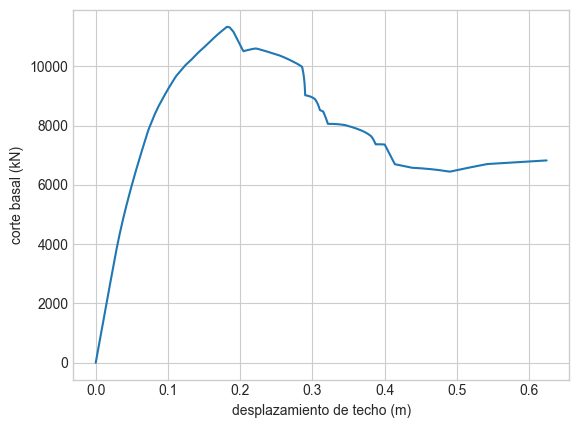

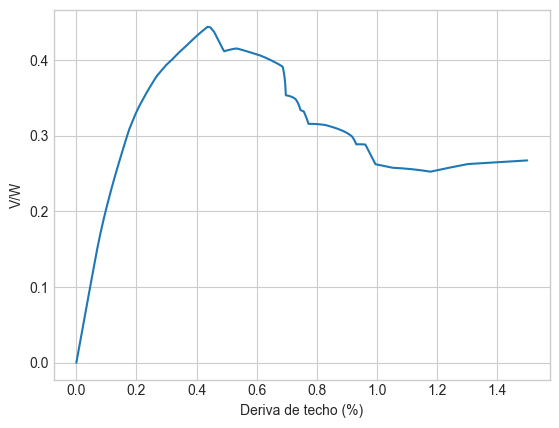

In [9]:
ctrl_node = max(getNodeTags())
Dmax = 0.015 * ht
Dincr = 0.0001 # Paso de 0.1 mm

print(f"Iniciando Pushover MVLEM (Control nodo {ctrl_node} en H = {ht} m)...\n")
stime = time.time()
dtecho, Vbasal = an.pushover2(Dmax, Dincr, ctrl_node, 1, [ht, W_total], Tol=1e-6)
etime = time.time()

dtecho = np.array(dtecho)
Vbasal = np.array(Vbasal)
roof_drift_pct = (dtecho / ht) * 100.0
coeff_V_W = Vbasal / W_total

d_ult = dtecho[-1] if len(dtecho) > 0 else 0.0
v_max = max(Vbasal) if len(Vbasal) > 0 else 0.0
cw_max = max(coeff_V_W) if len(coeff_V_W) > 0 else 0.0

print(f"🏁 Pushover completado en {etime - stime:.2f} s.")
print(f"   Desplazamiento máximo: {d_ult:.4f} m (Roof Drift: {roof_drift_pct[-1]:.2f}%)")
print(f"   Cortante basal máximo: {v_max:.2f} kN (Coeficiente V/W: {cw_max:.3f})")

### 📊 10. Gráficas Didácticas de Respuesta No Lineal
1. **Curva de Capacidad Adimensional:** Coeficiente sísmico de cortante basal ($V_b / W$) vs. Deriva de cubierta (*Roof Drift Ratio* $\Delta/H \times 100\%$).
2. **Curva de Capacidad Dimensional:** Cortante basal $V_b$ [kN] vs. Desplazamiento lateral de cubierta $\Delta_{techo}$ [m].

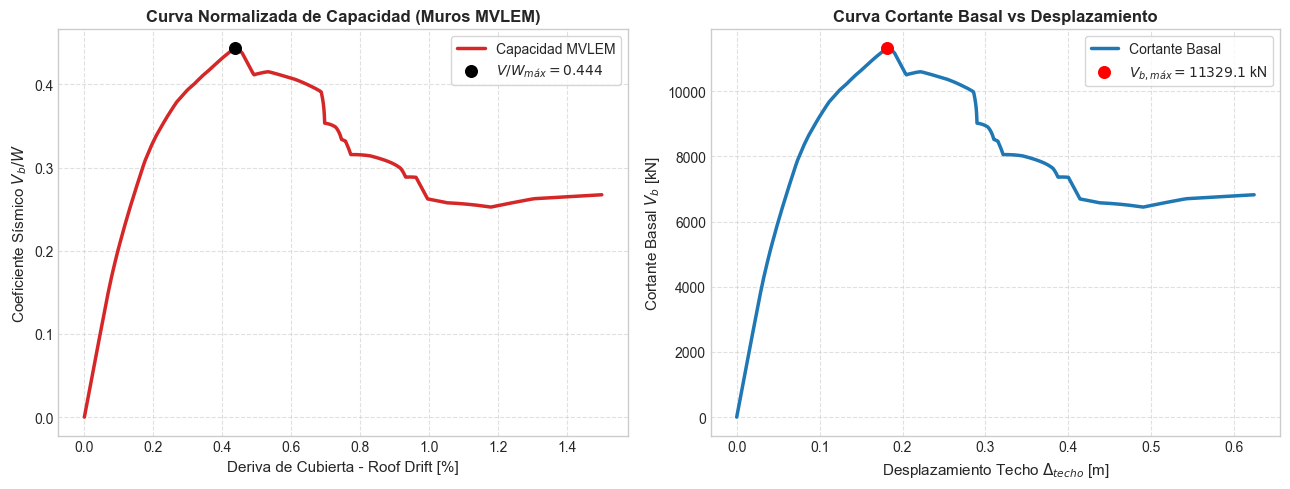

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Curva Normalizada V/W vs Roof Drift %
ax1.plot(roof_drift_pct, coeff_V_W, color="#d62728", linewidth=2.5, label="Capacidad MVLEM")
ax1.scatter([roof_drift_pct[np.argmax(coeff_V_W)]], [cw_max], color="black", s=70, zorder=5,
            label=f"$V/W_{{máx}} = {cw_max:.3f}$")
ax1.set_title("Curva Normalizada de Capacidad (Muros MVLEM)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Deriva de Cubierta - Roof Drift [%]", fontsize=11)
ax1.set_ylabel("Coeficiente Sísmico $V_b / W$", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(frameon=True, facecolor="white", fontsize=10)

# 2. Cortante Basal vs Desplazamiento
ax2.plot(dtecho, Vbasal, color="#1f77b4", linewidth=2.5, label="Cortante Basal")
ax2.scatter([dtecho[np.argmax(Vbasal)]], [v_max], color="red", s=70, zorder=5,
            label=f"$V_{{b,máx}} = {v_max:.1f}$ kN")
ax2.set_title("Curva Cortante Basal vs Desplazamiento", fontsize=12, fontweight="bold")
ax2.set_xlabel(r"Desplazamiento Techo $\Delta_{techo}$ [m]", fontsize=11)
ax2.set_ylabel(r"Cortante Basal $V_b$ [kN]", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(frameon=True, facecolor="white", fontsize=10)

plt.tight_layout()
plt.show()